In [84]:
# Mount google drive
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [85]:
# Path of directory
drive_path = "/content/drive/MyDrive"
root_path = f"{drive_path}/master/mxene-solvent-nrc/code-data/dataset/"

In [86]:
import pandas as pd

In [87]:
# Load data
df_mx_solvent_data_labeled = pd.read_pickle(f"{root_path}/dataset_mx_additive_solvent_hsp.pkl")
df_mx_solvent_data_labeled.columns = df_mx_solvent_data_labeled.columns.str.lower()
print(df_mx_solvent_data_labeled.shape)
df_mx_solvent_data_labeled.head()

(3726, 80)


,mx,inchikey_additive,inchikey_solvent,label,gap_oh,work_function_oh,formation_energy_oh,ehull_oh,alphax_el_oh,alphay_el_oh,...,heavy_atom_count_additive,isotope_atom_count_additive,atom_stereo_count_additive,bond_stereo_count_additive,covalent_unit_count_additive,solvent,additive,method_hf,method_licl/hf,method_lif/hcl
0,Ti3C2,SVMUEEINWGBIPD-UHFFFAOYSA-N,HEDRZPFGACZZDS-UHFFFAOYSA-N,1,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,...,16,0,0,0,1,chloroform,dodecylphosphonic acid,False,False,True
1,Ti3C2,SVMUEEINWGBIPD-UHFFFAOYSA-N,ZSIAUFGUXNUGDI-UHFFFAOYSA-N,1,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,...,16,0,0,0,1,hexan-1-ol,dodecylphosphonic acid,False,False,True
2,Ti3C2,SVMUEEINWGBIPD-UHFFFAOYSA-N,WYURNTSHIVDZCO-UHFFFAOYSA-N,1,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,...,16,0,0,0,1,oxolane,dodecylphosphonic acid,False,False,True
3,Ti3C2,SVMUEEINWGBIPD-UHFFFAOYSA-N,CSCPPACGZOOCGX-UHFFFAOYSA-N,1,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,...,16,0,0,0,1,propan-2-one,dodecylphosphonic acid,False,False,True
4,Ti3C2,SVMUEEINWGBIPD-UHFFFAOYSA-N,WEVYAHXRMPXWCK-UHFFFAOYSA-N,1,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,...,16,0,0,0,1,acetonitrile,dodecylphosphonic acid,False,False,True


In [88]:
cols_to_keep = [col for col in df_mx_solvent_data_labeled.columns if not (df_mx_solvent_data_labeled[col].nunique() <= 1)]
df_mx_solvent_data_labeled = df_mx_solvent_data_labeled[cols_to_keep]

In [89]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import xgboost as xgb

In [90]:
df_mx_solvent_data_labeled['method_hf'] = df_mx_solvent_data_labeled['method_hf'].astype('category').cat.codes
df_mx_solvent_data_labeled['method_licl/hf'] = df_mx_solvent_data_labeled['method_licl/hf'].astype('category').cat.codes
df_mx_solvent_data_labeled['method_lif/hcl'] = df_mx_solvent_data_labeled['method_lif/hcl'].astype('category').cat.codes

In [91]:
df_mx_solvent_data_labeled.head()

,mx,inchikey_additive,inchikey_solvent,label,work_function_oh,formation_energy_oh,ehull_oh,alphax_el_oh,alphay_el_oh,alphaz_el_oh,...,rotatable_bond_count_additive,heavy_atom_count_additive,atom_stereo_count_additive,bond_stereo_count_additive,covalent_unit_count_additive,solvent,additive,method_hf,method_licl/hf,method_lif/hcl
0,Ti3C2,SVMUEEINWGBIPD-UHFFFAOYSA-N,HEDRZPFGACZZDS-UHFFFAOYSA-N,1,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,11,16,0,0,1,chloroform,dodecylphosphonic acid,0,0,1
1,Ti3C2,SVMUEEINWGBIPD-UHFFFAOYSA-N,ZSIAUFGUXNUGDI-UHFFFAOYSA-N,1,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,11,16,0,0,1,hexan-1-ol,dodecylphosphonic acid,0,0,1
2,Ti3C2,SVMUEEINWGBIPD-UHFFFAOYSA-N,WYURNTSHIVDZCO-UHFFFAOYSA-N,1,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,11,16,0,0,1,oxolane,dodecylphosphonic acid,0,0,1
3,Ti3C2,SVMUEEINWGBIPD-UHFFFAOYSA-N,CSCPPACGZOOCGX-UHFFFAOYSA-N,1,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,11,16,0,0,1,propan-2-one,dodecylphosphonic acid,0,0,1
4,Ti3C2,SVMUEEINWGBIPD-UHFFFAOYSA-N,WEVYAHXRMPXWCK-UHFFFAOYSA-N,1,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,11,16,0,0,1,acetonitrile,dodecylphosphonic acid,0,0,1


In [92]:
df_mx_solvent_data_labeled.columns

Index(['mx', 'inchikey_additive', 'inchikey_solvent', 'label',
       'work_function_oh', 'formation_energy_oh', 'ehull_oh', 'alphax_el_oh',
       'alphay_el_oh', 'alphaz_el_oh', 'plasmafrequency_x_oh',
       'plasmafrequency_y_oh', 'has_inversion_symmetry_oh', 'gap_o',
       'work_function_o', 'formation_energy_o', 'ehull_o', 'alphax_el_o',
       'alphay_el_o', 'alphaz_el_o', 'plasmafrequency_x_o',
       'plasmafrequency_y_o', 'has_inversion_symmetry_o', 'work_function_f',
       'formation_energy_f', 'ehull_f', 'alphax_el_f', 'alphay_el_f',
       'alphaz_el_f', 'plasmafrequency_x_f', 'plasmafrequency_y_f',
       'has_inversion_symmetry_f', 'delta_d', 'delta_p', 'delta_h',
       'molar_volume', 'molecular_weight', 'xlogp', 'tpsa', 'complexity',
       'h_bond_donor_count', 'h_bond_acceptor_count', 'rotatable_bond_count',
       'heavy_atom_count', 'atom_stereo_count', 'boiling_point',
       'molecular_weight_additive', 'xlogp_additive', 'tpsa_additive',
       'complexity_add

In [93]:
features = ['work_function_oh', 'formation_energy_oh', 'ehull_oh', 'alphax_el_oh',
       'alphay_el_oh', 'alphaz_el_oh', 'plasmafrequency_x_oh',
       'plasmafrequency_y_oh', 'has_inversion_symmetry_oh', 'gap_o',
       'work_function_o', 'formation_energy_o', 'ehull_o', 'alphax_el_o',
       'alphay_el_o', 'alphaz_el_o', 'plasmafrequency_x_o',
       'plasmafrequency_y_o', 'has_inversion_symmetry_o', 'work_function_f',
       'formation_energy_f', 'ehull_f', 'alphax_el_f', 'alphay_el_f',
       'alphaz_el_f', 'plasmafrequency_x_f', 'plasmafrequency_y_f',
       'has_inversion_symmetry_f', 'delta_d', 'delta_p', 'delta_h',
       'molar_volume',
       'molecular_weight', 'xlogp', 'tpsa', 'complexity', 'h_bond_donor_count',
       'h_bond_acceptor_count', 'rotatable_bond_count', 'heavy_atom_count',
       'atom_stereo_count', 'boiling_point', 'molecular_weight_additive',
       'xlogp_additive', 'tpsa_additive', 'complexity_additive',
       'h_bond_donor_count_additive', 'h_bond_acceptor_count_additive',
       'rotatable_bond_count_additive', 'heavy_atom_count_additive',
       'atom_stereo_count_additive', 'bond_stereo_count_additive',
       'covalent_unit_count_additive', 'method_hf',
       'method_licl/hf', 'method_lif/hcl']
X = df_mx_solvent_data_labeled[features]
y = df_mx_solvent_data_labeled['label']

In [94]:
X.head()

,work_function_oh,formation_energy_oh,ehull_oh,alphax_el_oh,alphay_el_oh,alphaz_el_oh,plasmafrequency_x_oh,plasmafrequency_y_oh,has_inversion_symmetry_oh,gap_o,...,h_bond_donor_count_additive,h_bond_acceptor_count_additive,rotatable_bond_count_additive,heavy_atom_count_additive,atom_stereo_count_additive,bond_stereo_count_additive,covalent_unit_count_additive,method_hf,method_licl/hf,method_lif/hcl
0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,5.064378,0,0.477608,...,2,3,11,16,0,0,1,0,0,1
1,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,5.064378,0,0.477608,...,2,3,11,16,0,0,1,0,0,1
2,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,5.064378,0,0.477608,...,2,3,11,16,0,0,1,0,0,1
3,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,5.064378,0,0.477608,...,2,3,11,16,0,0,1,0,0,1
4,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,5.064378,0,0.477608,...,2,3,11,16,0,0,1,0,0,1


In [95]:
y.head()

,label
0,1
1,1
2,1
3,1
4,1


In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

In [97]:
def plot_feature_distributions(data, features, title, plots_per_row=4):
    num_features = len(features)
    num_rows = (num_features + plots_per_row - 1) // plots_per_row
    fig, axes = plt.subplots(num_rows, plots_per_row, figsize=(plots_per_row * 4, num_rows * 3))
    axes = axes.flatten()

    for i, feature in enumerate(features):
        sns.histplot(data[feature], kde=True, ax=axes[i], bins=30, color='skyblue')
        axes[i].set_title(f"{title}: {feature}")

    # Turn off any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

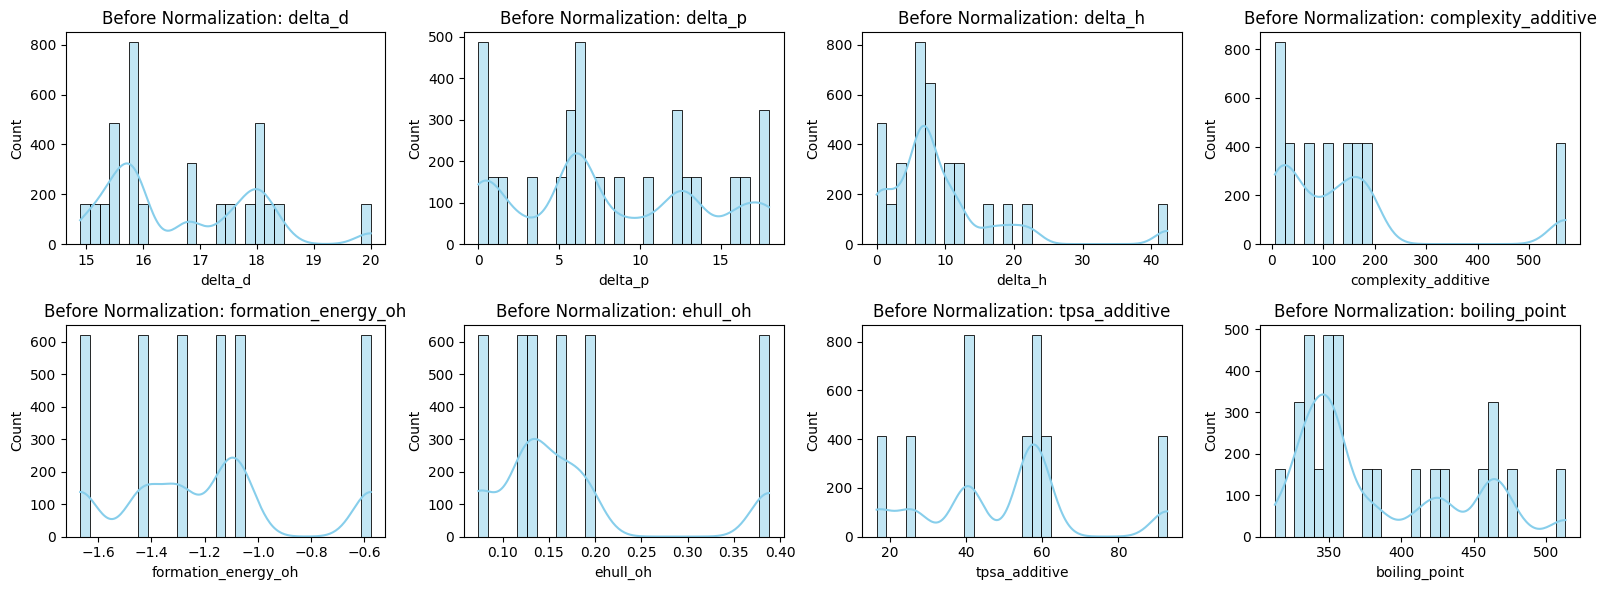

In [98]:
plot_feature = ['delta_d', 'delta_p', 'delta_h',
        'complexity_additive',
   'formation_energy_oh','ehull_oh', 'tpsa_additive',
   'boiling_point']
plot_feature_distributions(X, plot_feature, "Before Normalization")

In [99]:
from sklearn.preprocessing import MinMaxScaler

In [100]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

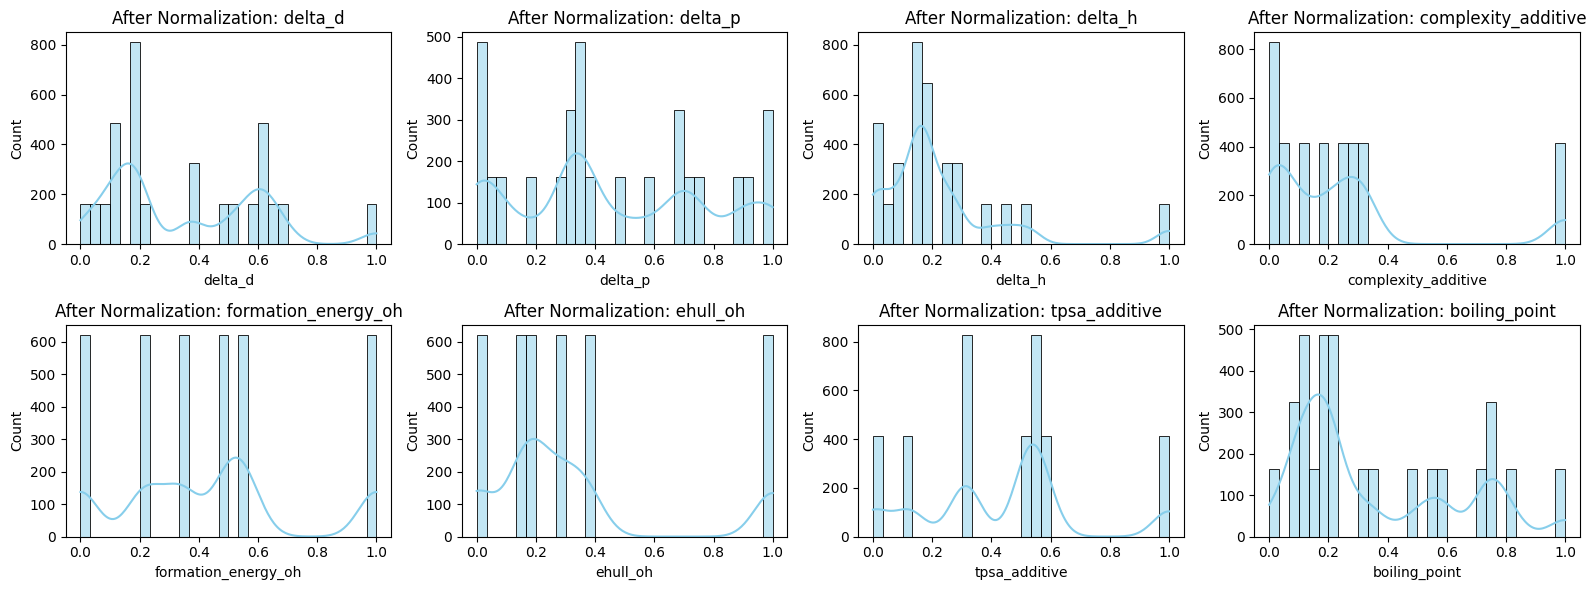

In [101]:
plot_feature_distributions(X_scaled_df, plot_feature, "After Normalization")

In [102]:
mask_pos = y == 1
mask_neg = y == -1
mask_unlabeled = y == 0


In [103]:
X_train = X_scaled[mask_pos | mask_neg]
y_train = y[mask_pos | mask_neg]

In [104]:
X_test = X_scaled[mask_unlabeled]
df_unlabeled = df_mx_solvent_data_labeled[mask_unlabeled].copy()

In [105]:
X_train_train, X_val, y_train_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

In [106]:
print(len(X_train_train))
print(len(X_val))
print(len(y_train_train))
print(len(y_val))

48
13
48
13


In [107]:
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score
from scipy.stats import randint, uniform

In [108]:
param_dist = {
    'estimator__learning_rate': uniform(0.01, 0.3),
    'estimator__n_estimators': randint(50, 200),
    'estimator__subsample': uniform(0.6, 0.4),
    'estimator__colsample_bytree': uniform(0.6, 0.4)
}

In [109]:
base_rf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', verbosity=0, base_score=0.5)
bagging_clf = BaggingClassifier(estimator=base_rf, n_estimators=10, random_state=42)

In [110]:
rand_search = RandomizedSearchCV(
    estimator=bagging_clf,
    param_distributions=param_dist,
    n_iter=30,
    scoring='accuracy',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=1
)
rand_search.fit(X_train_train, y_train_train)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
[CV] END estimator__colsample_bytree=0.749816047538945, estimator__learning_rate=0.2952142919229748, estimator__n_estimators=156, estimator__subsample=0.9118764001091078; total time=   0.3s
[CV] END estimator__colsample_bytree=0.749816047538945, estimator__learning_rate=0.2952142919229748, estimator__n_estimators=156, estimator__subsample=0.9118764001091078; total time=   0.3s
[CV] END estimator__colsample_bytree=0.749816047538945, estimator__learning_rate=0.2952142919229748, estimator__n_estimators=156, estimator__subsample=0.9118764001091078; total time=   0.3s
[CV] END estimator__colsample_bytree=0.8387400631785948, estimator__learning_rate=0.14374982585607735, estimator__n_estimators=124, estimator__subsample=0.7836995567863468; total time=   0.3s
[CV] END estimator__colsample_bytree=0.8387400631785948, estimator__learning_rate=0.14374982585607735, estimator__n_estimators=124, estimator__subsample=0.7836995567863468; tota

RandomizedSearchCV(cv=3,
                   estimator=BaggingClassifier(estimator=XGBClassifier(base_score=0.5,
                                                                       booster=None,
                                                                       callbacks=None,
                                                                       colsample_bylevel=None,
                                                                       colsample_bynode=None,
                                                                       colsample_bytree=None,
                                                                       device=None,
                                                                       early_stopping_rounds=None,
                                                                       enable_categorical=False,
                                                                       eval_metric='logloss',
                                                                       feature_types=None,
                                                                       feature_weights=None,
                                                                       gamma=None,
                                                                       grow_policy=None,
                                                                       importance...
                                        'estimator__learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7f471b048f10>,
                                        'estimator__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f471b4e5350>,
                                        'estimator__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7f471b4e4ed0>},
                   random_state=42, scoring='accuracy', verbose=2)

In [111]:
best_model = rand_search.best_estimator_
print(best_model)

BaggingClassifier(estimator=XGBClassifier(base_score=0.5, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=np.float64(0.749816047538945),
                                          device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric='logloss',
                                          feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints=None,
                                          learning_rate=n

In [112]:
y_train_pred = best_model.predict(X_train)
y_val_pred = best_model.predict(X_val)

print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Val Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation Report:\n", classification_report(y_val, y_val_pred))

Train Accuracy: 0.9672131147540983
Val Accuracy: 0.9230769230769231
Validation Report:
               precision    recall  f1-score   support

          -1       0.00      0.00      0.00         1
           1       0.92      1.00      0.96        12

    accuracy                           0.92        13
   macro avg       0.46      0.50      0.48        13
weighted avg       0.85      0.92      0.89        13



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [113]:
proba_unlabeled = best_model.predict_proba(X_test)[:, 1]  # Probability of class 1 (positive)
df_unlabeled['predicted_proba'] = proba_unlabeled
df_unlabeled['predicted_label'] = (proba_unlabeled >= 0.5).astype(int)

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns

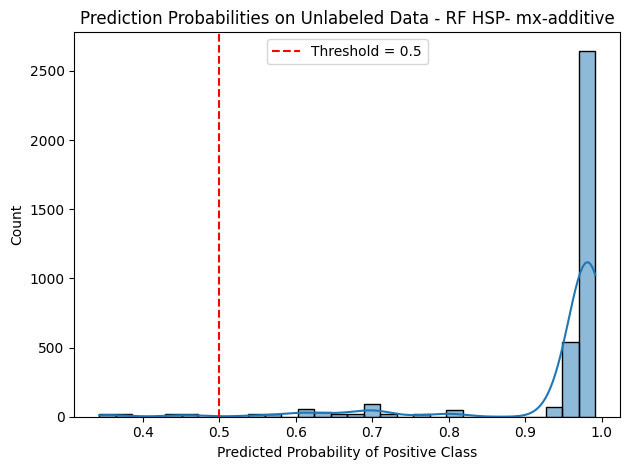

In [115]:
sns.histplot(proba_unlabeled, bins=30, kde=True)
plt.axvline(0.5, color='red', linestyle='--', label='Threshold = 0.5')
plt.title("Prediction Probabilities on Unlabeled Data - RF HSP- mx-additive")
plt.xlabel("Predicted Probability of Positive Class")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

In [116]:
high_conf = df_unlabeled[df_unlabeled['predicted_proba'] >= 0.9]
high_conf = high_conf[high_conf['predicted_proba'] < 0.99]
top_10 = high_conf.sort_values(by='predicted_proba', ascending=False).head(20)
print(top_10[['solvent', 'mx', 'additive','predicted_proba', 'method_lif/hcl', 'method_licl/hf', 'method_hf']])

          solvent     mx                                           additive  \
3682  cyclohexane  Ti4N3                              phenylphosphonic acid   
788   cyclohexane  Ti2C1                              phenylphosphonic acid   
787   cyclohexane  Ti2C1                             dodecylphosphonic acid   
792   cyclohexane  Ti2C1                  5-(2-methoxyethoxy)pentanoic acid   
789   cyclohexane  Ti2C1  3,3,4,4,5,5,6,6,6-nonafluorohexyl 2-amino-3-(3...   
2234  cyclohexane   V2C1                             dodecylphosphonic acid   
2030  cyclohexane   V2C1  3,3,4,4,5,5,6,6,6-nonafluorohexyl 2-amino-3-(3...   
2029  cyclohexane   V2C1                              phenylphosphonic acid   
2236  cyclohexane   V2C1  3,3,4,4,5,5,6,6,6-nonafluorohexyl 2-amino-3-(3...   
2235  cyclohexane   V2C1                              phenylphosphonic acid   
999   cyclohexane  Ti2C1                  5-(2-methoxyethoxy)pentanoic acid   
996   cyclohexane  Ti2C1  3,3,4,4,5,5,6,6,6-nonafluo

In [117]:
low_conf = df_unlabeled[df_unlabeled['predicted_proba'] <= 0.4]
bottom_10 = low_conf.sort_values(by='predicted_proba', ascending=True).head(20)

print("MXene-solvent pairs predicted to NOT work at all (P ≤ 0.1):")
print(bottom_10[['solvent', 'mx', 'additive','predicted_proba', 'method_lif/hcl', 'method_licl/hf', 'method_hf']])

MXene-solvent pairs predicted to NOT work at all (P ≤ 0.1):
       solvent     mx                        additive  predicted_proba  \
180    oxidane  Ti3C2  benzyl(methyl)azanium;chloride         0.343176   
383    oxidane  Ti3C2  benzyl(methyl)azanium;chloride         0.343176   
772    oxidane  Ti2C1  benzyl(methyl)azanium;chloride         0.343176   
979    oxidane  Ti2C1  benzyl(methyl)azanium;chloride         0.343176   
1393   oxidane  Nb2C1  benzyl(methyl)azanium;chloride         0.343176   
1599   oxidane  Nb2C1  benzyl(methyl)azanium;chloride         0.343176   
1186   oxidane  Ti2C1  benzyl(methyl)azanium;chloride         0.343176   
1806   oxidane  Nb2C1  benzyl(methyl)azanium;chloride         0.343176   
2633   oxidane  Mo2C1  benzyl(methyl)azanium;chloride         0.343176   
2839   oxidane  Mo2C1  benzyl(methyl)azanium;chloride         0.343176   
3253   oxidane  Ti4N3  benzyl(methyl)azanium;chloride         0.343176   
3046   oxidane  Mo2C1  benzyl(methyl)azanium;chlorid

In [118]:
print("\n=== Summary of predicted probabilities on unlabeled data ===")
print(df_unlabeled['predicted_proba'].describe())

# Count how many samples fall into different confidence zones
bins = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
labels = ['Very Low (≤0.1)', 'Low (0.1–0.3)', 'Mid (0.3–0.5)',
          'High (0.5–0.7)', 'Very High (0.7–0.9)', 'Extremely High (>0.9)']

df_unlabeled['confidence_bin'] = pd.cut(df_unlabeled['predicted_proba'], bins=bins, labels=labels, include_lowest=True)
print("\n=== Prediction count by confidence bin ===")
print(df_unlabeled['confidence_bin'].value_counts().sort_index())


=== Summary of predicted probabilities on unlabeled data ===
count    3665.000000
mean        0.941349
std         0.116686
min         0.343176
25%         0.967920
50%         0.981615
75%         0.987455
max         0.991619
Name: predicted_proba, dtype: float64

=== Prediction count by confidence bin ===
confidence_bin
Very Low (≤0.1)             0
Low (0.1–0.3)               0
Mid (0.3–0.5)              69
High (0.5–0.7)            196
Very High (0.7–0.9)       140
Extremely High (>0.9)    3260
Name: count, dtype: int64


In [119]:
train_path = f"{drive_path}/master/mxene-solvent-nrc/code-data/training/final/hsp/"

In [120]:
df_unlabeled.to_csv(f"{train_path}/006_p_vs_n_predictions_unlabeled_xg-normalize-fintune-mxadd.csv")
df_unlabeled.to_pickle(f"{train_path}/006_p_vs_n_predictions_unlabeled_xg-normalize-fintune-mxadd.pkl")


                         feature  importance
43                xlogp_additive    0.263798
44                 tpsa_additive    0.226731
29                       delta_p    0.077640
52  covalent_unit_count_additive    0.052935
30                       delta_h    0.051042
31                  molar_volume    0.041855
33                         xlogp    0.039934
45           complexity_additive    0.039297
32              molecular_weight    0.023094
28                       delta_d    0.022975


/tmp/ipython-input-849015670.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df.head(10), palette='viridis')


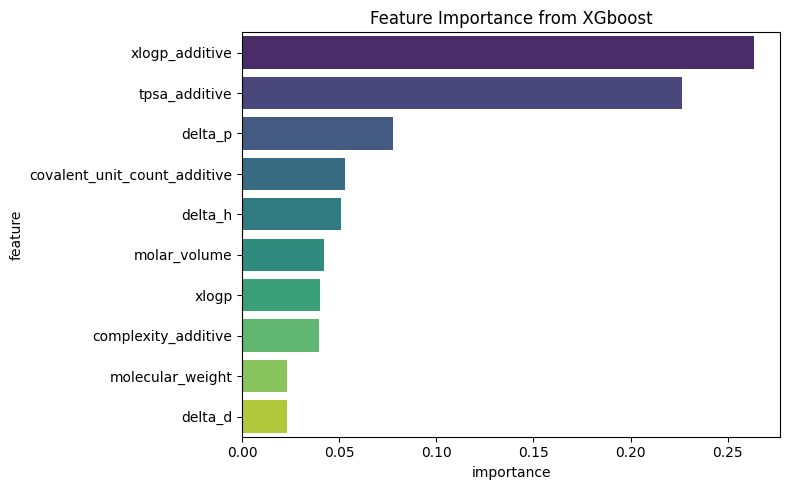

In [121]:
feature_names = X.columns

# Later, after training
importances = np.array([tree.feature_importances_ for tree in best_model.estimators_])
mean_importance = np.mean(importances, axis=0)

# Use saved feature_names directly
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': mean_importance
}).sort_values(by='importance', ascending=False)

print(feature_importance_df.head(10))

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(10), palette='viridis')
plt.title('Feature Importance from XGboost')
plt.tight_layout()
plt.show()

In [122]:
mx_features = ['work_function_oh', 'formation_energy_oh', 'ehull_oh', 'alphax_el_oh',
       'alphay_el_oh', 'alphaz_el_oh', 'plasmafrequency_x_oh',
       'plasmafrequency_y_oh', 'has_inversion_symmetry_oh', 'gap_o',
       'work_function_o', 'formation_energy_o', 'ehull_o', 'alphax_el_o',
       'alphay_el_o', 'alphaz_el_o', 'plasmafrequency_x_o',
       'plasmafrequency_y_o', 'has_inversion_symmetry_o', 'work_function_f',
       'formation_energy_f', 'ehull_f', 'alphax_el_f', 'alphay_el_f',
       'alphaz_el_f', 'plasmafrequency_x_f', 'plasmafrequency_y_f',
       'has_inversion_symmetry_f']
solv_features = ['δd', 'δp', 'δh', 'molarvolume',
       'molecular_weight', 'xlogp', 'tpsa', 'complexity', 'h_bond_donor_count',
       'h_bond_acceptor_count', 'rotatable_bond_count', 'heavy_atom_count',
       'atom_stereo_count', 'boiling_point']
add_features = ['molecular_weight_additive',
       'xlogp_additive', 'tpsa_additive', 'complexity_additive',
       'h_bond_donor_count_additive', 'h_bond_acceptor_count_additive',
       'rotatable_bond_count_additive', 'heavy_atom_count_additive',
       'atom_stereo_count_additive', 'bond_stereo_count_additive',
       'covalent_unit_count_additive']



In [123]:
top_mx = feature_importance_df[feature_importance_df['feature'].isin(mx_features)] \
            .sort_values(by='importance', ascending=False) \
            .head(5)

# Top 5 from Solvent features
top_solv = feature_importance_df[feature_importance_df['feature'].isin(solv_features)] \
              .sort_values(by='importance', ascending=False) \
              .head(5)

top_add = feature_importance_df[feature_importance_df['feature'].isin(add_features)] \
              .sort_values(by='importance', ascending=False) \
              .head(5)

# Display
print("Total  MXene Features:", len(mx_features))
print("Top 5 MXene Features:")
print(top_mx.to_string(index=False))

print("\nTotal  Solvent Features:", len(solv_features))
print("Top 5 Solvent Features:")
print(top_solv.to_string(index=False))

print("\nTotal  Additive Features:", len(add_features))
print("Top 5 Additive Features:")
print(top_add.to_string(index=False))

Total  MXene Features: 28
Top 5 MXene Features:
            feature  importance
   work_function_oh         0.0
           ehull_oh         0.0
formation_energy_oh         0.0
       alphay_el_oh         0.0
       alphaz_el_oh         0.0

Total  Solvent Features: 14
Top 5 Solvent Features:
              feature  importance
                xlogp    0.039934
     molecular_weight    0.023094
h_bond_acceptor_count    0.017212
           complexity    0.009280
                 tpsa    0.007713

Total  Additive Features: 11
Top 5 Additive Features:
                     feature  importance
              xlogp_additive    0.263798
               tpsa_additive    0.226731
covalent_unit_count_additive    0.052935
         complexity_additive    0.039297
   molecular_weight_additive    0.022558
